<a href="https://colab.research.google.com/github/SarthakData2026/AI_IN_DATA_SCIENCE/blob/main/diabetes_using_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction Using KNN

This notebook contains the original Python code organized into Jupyter Notebook cells.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Import Dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# import file
from google.colab import files
uploaded = files.upload()



Saving diabetes.csv.xls to diabetes.csv.xls


In [3]:
df = pd.read_csv('diabetes.csv.xls', encoding='utf-8-sig')

In [4]:
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## Dataset Information


In [5]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())


Shape of dataset: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
Missing values:
Preg

## Handle Missing / Zero Values


In [6]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols] = df[cols].replace(0, np.nan)

for col in cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Prepare Features and Target


In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


## Train-Test Split


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (614, 8)
Testing data: (154, 8)


## KNN Model


In [9]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

print("KNN model trained successfully.")


KNN model trained successfully.


## Predictions


In [10]:
y_pred = knn.predict(X_test)

print("Predictions:")
print(y_pred)


Predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]


## Model Accuracy


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)


Accuracy: 0.8506493506493507
Accuracy (%): 85.06493506493507


## Confusion Matrix


Confusion Matrix:
[[90 10]
 [13 41]]


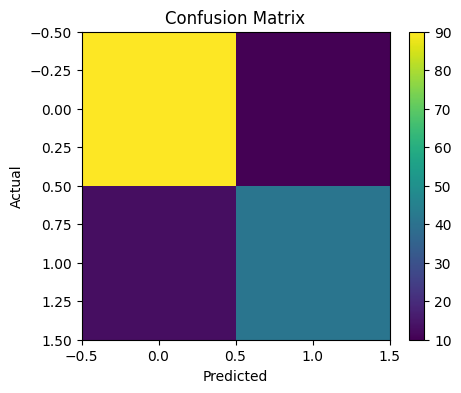

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.show()


<Axes: >

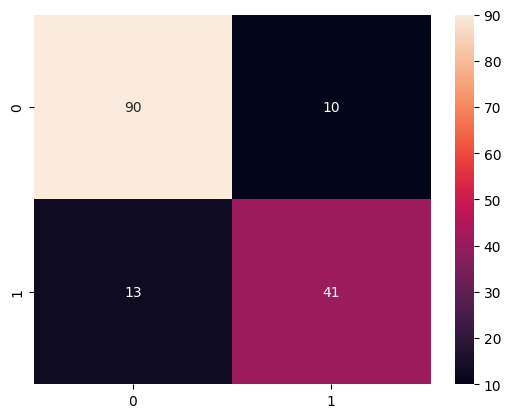

In [13]:
#heat map of confusion matrix
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

## Classification Report


In [14]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       100
           1       0.80      0.76      0.78        54

    accuracy                           0.85       154
   macro avg       0.84      0.83      0.83       154
weighted avg       0.85      0.85      0.85       154



In [15]:
from matplotlib.colors import ListedColormap
from ipywidgets import interact, fixed

# Ensure KNeighborsClassifier is available, which it is from previous imports
from sklearn.neighbors import KNeighborsClassifier

def plot_decision_boundaries(n_neighbors, data, labels):
    h = .02
    cmap_light = ListedColormap(['orange', 'blue'])
    cmap_bold = ListedColormap(['darkorange', 'darkblue'])

    # Use KNeighborsClassifier directly, as it's already imported
    clf = KNeighborsClassifier(n_neighbors)
    clf.fit(data, labels)

    # Check if data has at least two features for plotting
    if data.shape[1] < 2:
        print("Need at least two features to plot decision boundaries.")
        return

    # Create meshgrid for plotting decision boundaries
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict class for each point in the mesh
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Plot training points
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold, edgecolor='k', s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'2-Class classification (k = {n_neighbors})')
    plt.xlabel(X.columns[0]) # Label x-axis with the feature name
    plt.ylabel(X.columns[1]) # Label y-axis with the feature name
    plt.show()

# Prepare data for plotting from the existing diabetes dataset
# Using the first two features (Pregnancies and Glucose) for visualization
X_plot_raw = X.iloc[:, :2]
y_plot = y

# Standardize the selected features for plotting
scaler_plot = StandardScaler()
X_plot = scaler_plot.fit_transform(X_plot_raw)

# Interactive widget
interact(plot_decision_boundaries, n_neighbors=(1, 20), data=fixed(X_plot), labels=fixed(y_plot))

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

<function __main__.plot_decision_boundaries(n_neighbors, data, labels)>